In [ ]:
from spacerocks import SpaceRock
from spacerocks.time import Time
from spacerocks.observing import Observatory
from spacerocks.spice import SpiceKernel
from spacerocks.nbody import Simulation, Force

from astroquery.jplhorizons import Horizons

from astropy.time import Time as AstropyTime

import numpy as np


import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

kernel = SpiceKernel()

kernel.load_spk("/Users/kjnapier/data/spice/sb441-n16.bsp")
kernel.load_spk("/Users/kjnapier/data/spice/de440s.bsp")
kernel.load_bpc("/Users/kjnapier/data/spice/earth_1962_240827_2124_combined.bpc")

In [2]:
obscode = 'F51'
name = 'holman'
w84 = Observatory.from_obscode(obscode)

In [3]:
epoch = Time.now()
t0 = epoch.epoch
epochs = np.arange(epoch.epoch - 0.0 * 365.25, epoch.epoch + 10.0 * 365.25, 1)
# epochs = np.arange(epoch.epoch, epoch.epoch + 30, 1)

testdates = AstropyTime(epochs, format='jd', scale='utc')

In [4]:
rock = SpaceRock.from_horizons(name=name, epoch=epoch, reference_plane='J2000', origin='ssb')



In [5]:
SpaceRock.from_spice("Earth", rock.epoch, "J2000", "ssb", kernel)

SpaceRock: Earth
position: [[-1.0012284790285273, -0.028805532880478855, -0.012292491290268912]]
velocity: [[0.000172966766417843, -0.01584129234102188, -0.006867143652991791]]
epoch: 2460756.7398263887 UTC JD
reference_plane: J2000
origin: SSB

In [6]:
o = w84.at(rock.epoch, kernel=kernel, reference_plane="J2000", origin="ssb")

In [7]:
sim = Simulation.horizons(rock.epoch, reference_plane="J2000", origin="ssb", kernel=kernel)

sim.add_force(Force.solar_gr())
sim.add_force(Force.solar_j2())
sim.add(rock)

In [8]:
ras = []
decs = []
for epoch in epochs:
    
    t = Time(epoch, 'utc', 'jd')
    sim.integrate(t)
    rock = sim.get_particle(name)
    observer = w84.at(t, reference_plane="J2000", origin="ssb", kernel=kernel)
    obs = rock.observe(observer)
    ras.append(np.degrees(obs.ra))
    decs.append(np.degrees(obs.dec))

ras = np.array(ras)
decs = np.array(decs)

In [9]:
ephem_Horizons = Horizons(id=name, 
                          location=obscode,
                          epochs={'start': testdates[0].iso, 
                                  'stop': testdates[-1].iso, 
                                  'step': '1d'}).ephemerides(extra_precision=True)

/Users/kjnapier/spacerocks/.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


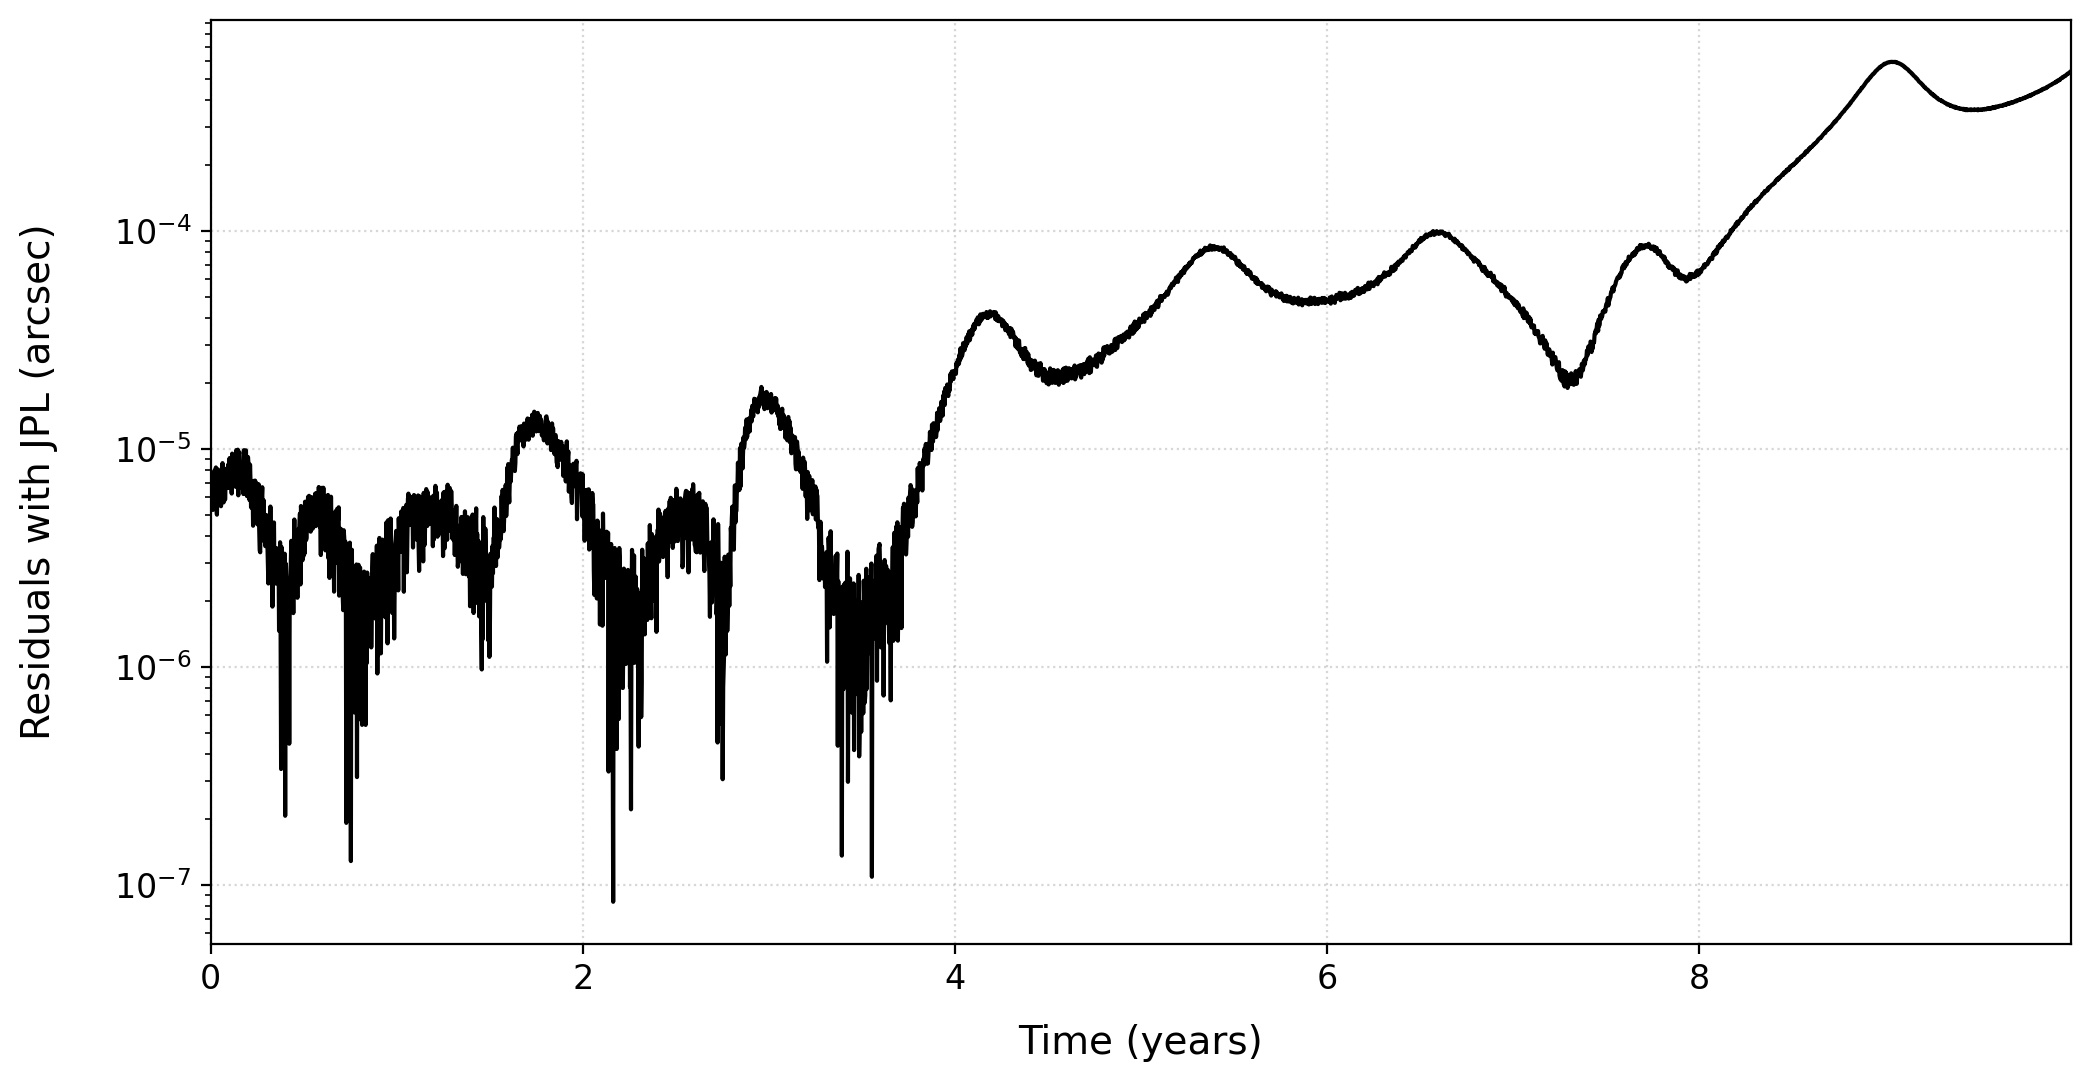

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ra_residuals = (ephem_Horizons['RA'] - ras) * 3600
dec_residuals = (ephem_Horizons['DEC'] - decs) * 3600
residuals = np.sqrt(ra_residuals**2 + dec_residuals**2)

t = (epochs - t0) / 365.25
ax.plot(t, residuals, label='Residuals', color='black')


ax.set_xlabel('Time (years)', fontsize=14, labelpad=10)
ax.set_ylabel('Residuals with JPL (arcsec)', fontsize=14, labelpad=20)
ax.tick_params(axis='both', which='major', labelsize=12)
#ax.set_ylim(bottom=1e-6)
ax.set_yscale('log')
ax.set_xlim(left=t.min(), right=t.max())
ax.grid(ls=':', alpha=0.5)

---

In [14]:
name = "hsingwenlin"

epoch = Time.now()
t0 = epoch.tdb().jd()
epochs = np.linspace(epoch.tdb().jd(), epoch.tdb().jd() + 365.25, 100)
rock = SpaceRock.from_horizons(name=name, epoch=epoch, reference_plane='J2000', origin='ssb')

In [15]:
true_positions = []
true_velocities = []
for epoch in epochs:
    t = Time(epoch, 'tdb', 'jd')
    tr = SpaceRock.from_horizons(name=name, epoch=t, reference_plane='J2000', origin='ssb')
    true_positions.append(tr.position)
    true_velocities.append(tr.velocity)

true_positions = np.array(true_positions)
true_velocities = np.array(true_velocities)

true_xs, true_ys, true_zs = true_positions.T
true_vxs, true_vys, true_vzs = true_velocities.T

In [16]:
dx = true_xs[0] - rock.position[0]
dy = true_ys[0] - rock.position[1]
dz = true_zs[0] - rock.position[2]
dvx = true_vxs[0] - rock.velocity[0]
dvy = true_vys[0] - rock.velocity[1]
dvz = true_vzs[0] - rock.velocity[2]

In [17]:
print(dx, dy, dz, dvx, dvy, dvz)

0.0 0.0 0.0 0.0 0.0 0.0


In [18]:
sim = Simulation.horizons(rock.epoch, reference_plane="J2000", origin="ssb", kernel=kernel)
sim.add_force(Force.solar_gr())
sim.add_force(Force.solar_j2())
sim.add(rock)

In [27]:
Time(2451544.5007428695, 'tdb', 'jd').calendar()

'1 Jan 2000'

In [20]:
positions = []
velocities = []
eps = []
for epoch in epochs:
    sim.integrate(Time(epoch, 'tdb', 'jd'))
    rock = sim.get_particle(name)
    positions.append(rock.position)
    velocities.append(rock.velocity)
    eps.append(rock.epoch.tdb().jd())

positions = np.array(positions)
velocities = np.array(velocities)
eps = np.array(eps)

In [21]:
sr_x, sr_y, sr_z = positions.T
sr_vx, sr_vy, sr_vz = velocities.T

In [22]:
METERS_PER_AU = 149597870700.0

In [23]:
dx = sr_x - true_xs
dy = sr_y - true_ys
dz = sr_z - true_zs
dvx = sr_vx - true_vxs
dvy = sr_vy - true_vys
dvz = sr_vz - true_vzs

absolute_dr = np.sqrt(dx**2 + dy**2 + dz**2) * METERS_PER_AU
absolute_dv = np.sqrt(dvx**2 + dvy**2 + dvz**2)

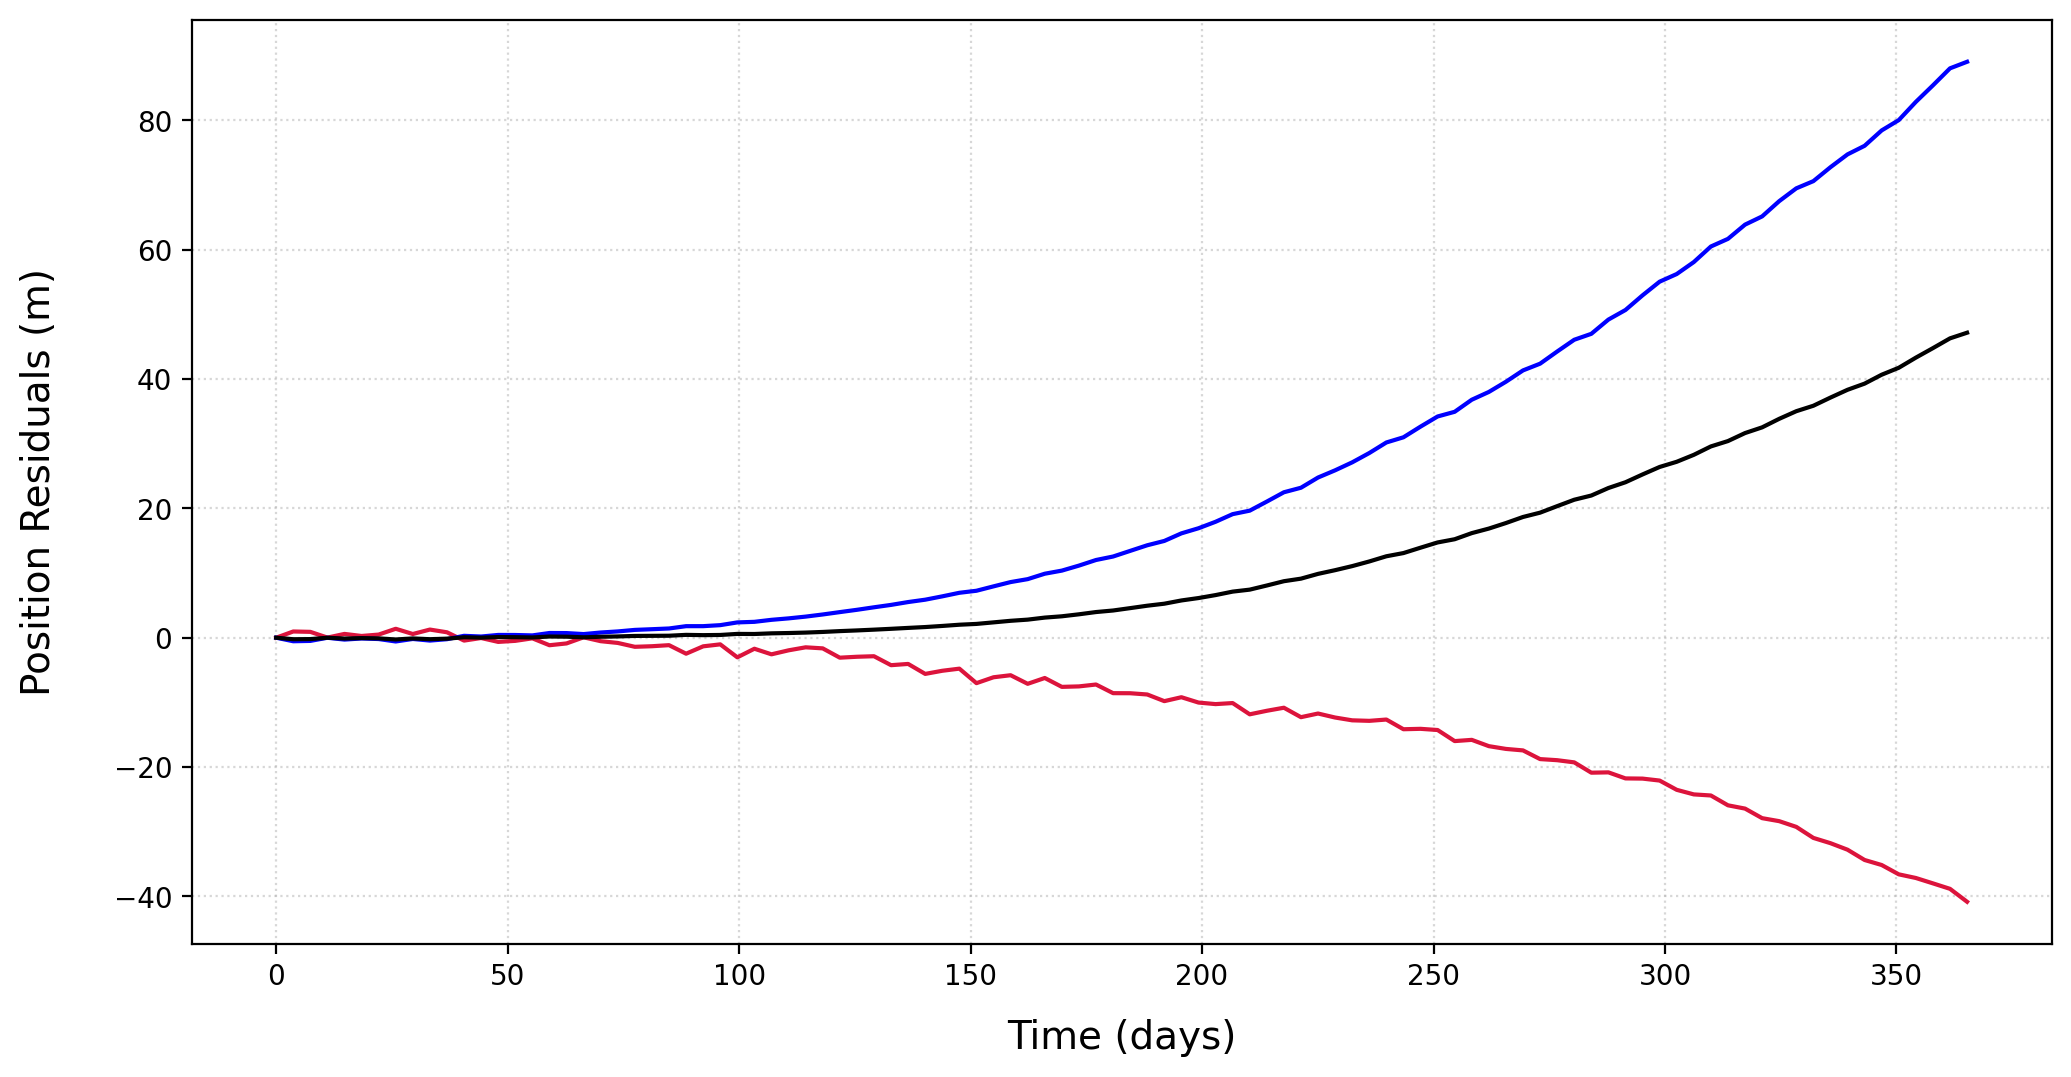

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot((epochs - epochs[0]), dx * METERS_PER_AU, label='Position Residuals (m)', color='crimson')
ax.plot((epochs - epochs[0]), dy * METERS_PER_AU, color='blue')
ax.plot((epochs - epochs[0]), dz * METERS_PER_AU, color='black')
ax.plot(fontsize=14)
#ax.set_yscale('log')
# ax.set_xlim(left=0, right=np.ceil((epochs[-1] - epochs[0])))
ax.set_xlabel('Time (days)', fontsize=14, labelpad=10)
ax.set_ylabel('Position Residuals (m)', fontsize=14, labelpad=20)
ax.grid(ls=':', alpha=0.5, which='both')
#ax.set_xscale('log')

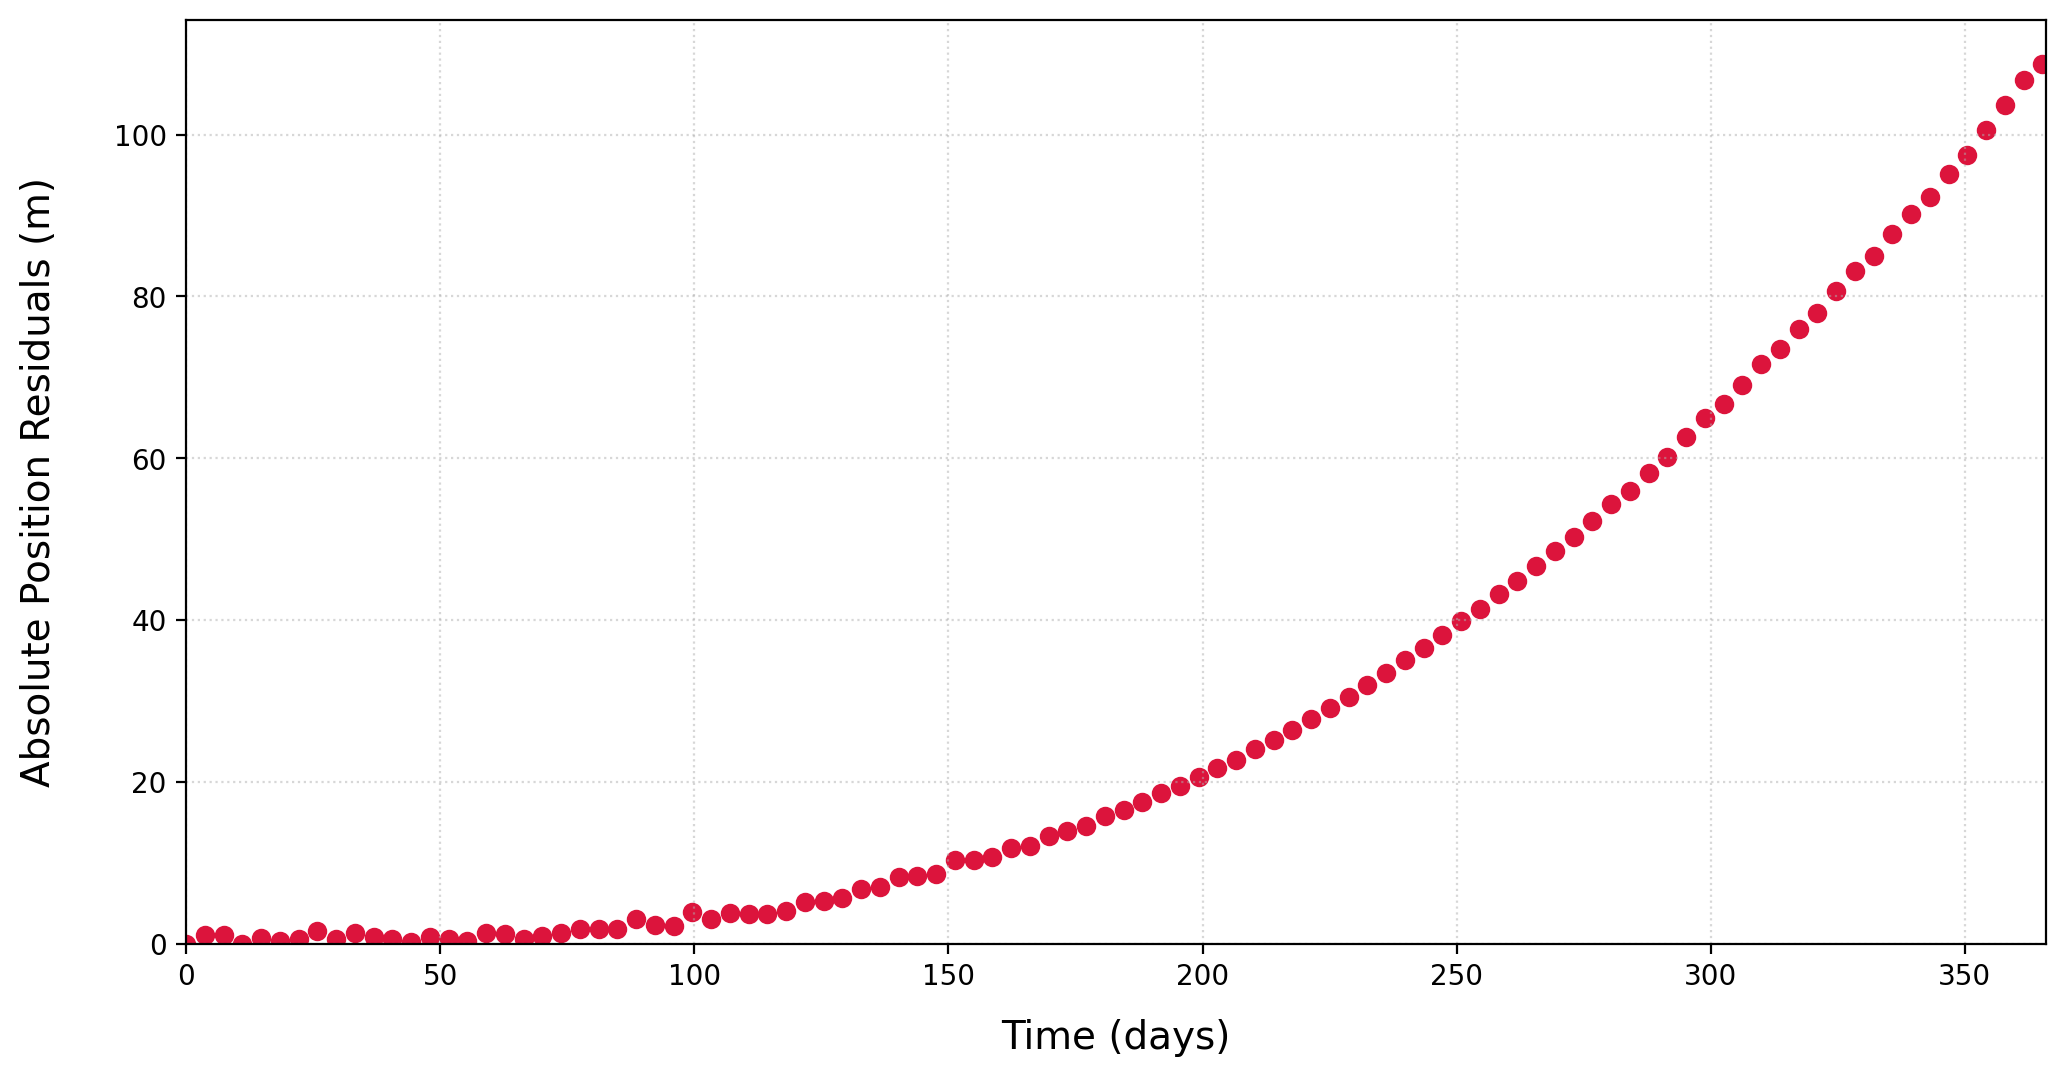

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.scatter((epochs - epochs[0]), absolute_dr, label='Position Residuals', color='crimson')
#ax#.scatter((epochs - epochs[0]) / 365.25, absolute_dv, label='Velocity Residuals', color='black')
#ax.legend(fontsize=14)
#x.set_yscale('log')
# ax.set_xlim(left=0, right=1)
ax.set_xlabel('Time (days)', fontsize=14, labelpad=10)
ax.set_ylabel('Absolute Position Residuals (m)', fontsize=14, labelpad=20)
ax.set_ylim(bottom=0)
ax.set_xlim(left=0, right=np.ceil((epochs[-1] - epochs[0])))
ax.grid(ls=':', alpha=0.5)

ValueError: x and y must be the same size

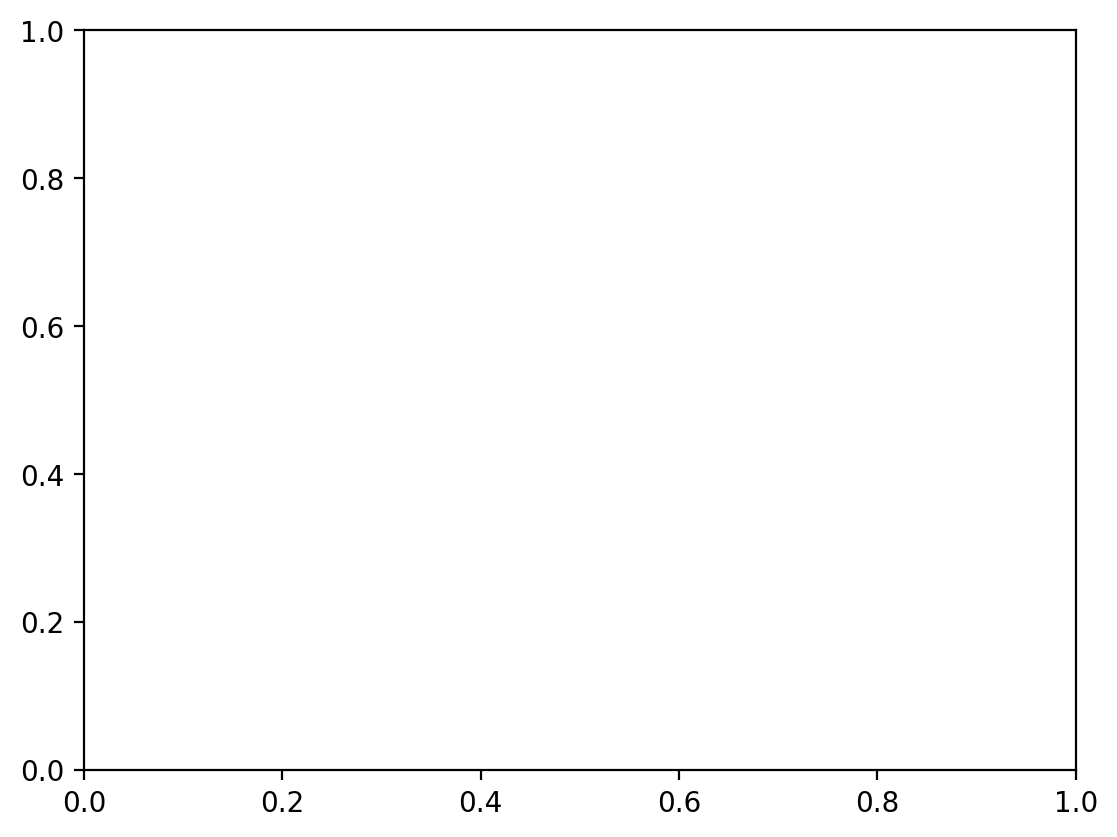

In [22]:
plt.scatter(t, ra_residuals, s=10)
plt.scatter(t, dec_residuals, s=10)
plt.yscale('log')

In [23]:
epoch = Time.now()
name = "holman"
rock = SpaceRock.from_horizons(name=name, epoch=epoch, reference_plane='J2000', origin='ssb')

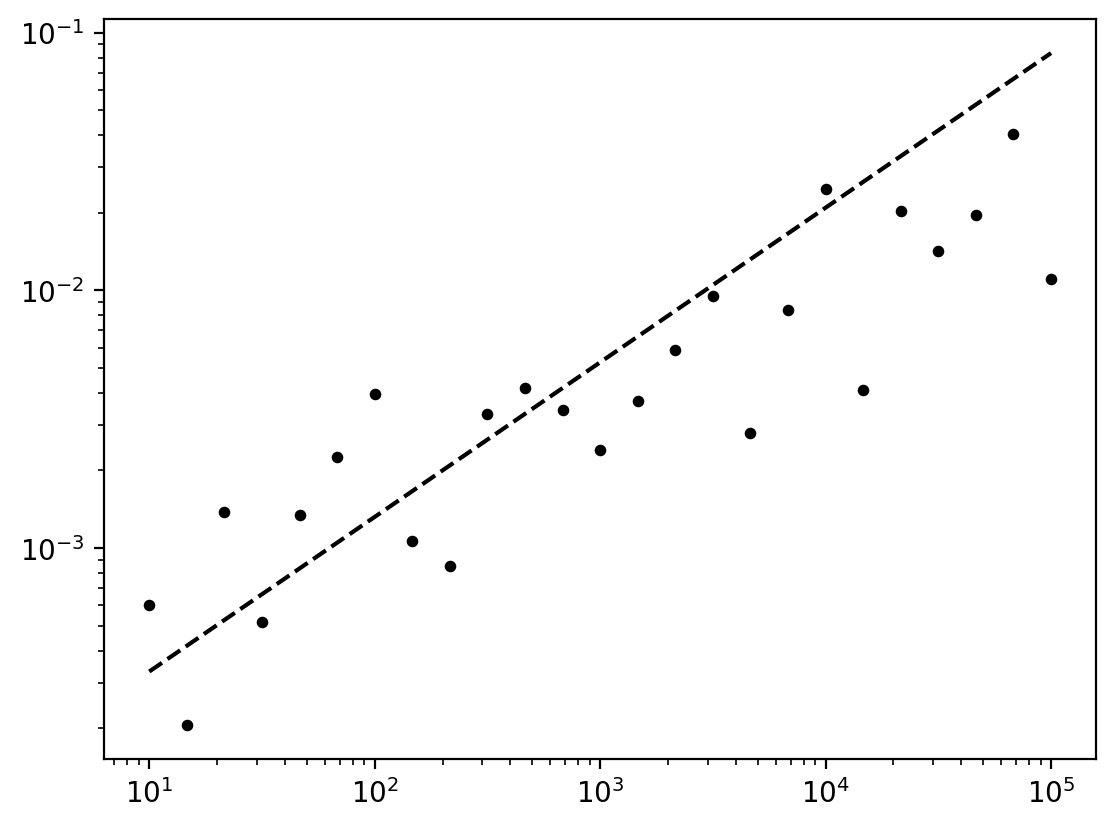

In [24]:
ds = []
dts = np.logspace(1, 5, 25)
for dt in dts:
    sim = Simulation.horizons(rock.epoch, reference_plane="J2000", origin="ssb")
    sim.add_force(Force.solar_gr())
    sim.add_force(Force.solar_j2())
    sim.add(rock)

    sim.integrate(epoch + dt)
    sim.integrate(epoch)
    sr = sim.get_particle(name)
    d_pos = np.array(sr.position) - np.array(rock.position)
    ds.append(np.sqrt(np.sum(d_pos**2)).item())

ds = np.array(ds)
ds = ds * 149597870700.0 / 1000

plt.scatter(dts[:len(ds)], ds, color='black', s=10, label='Holman')
plt.xscale('log')
plt.yscale('log')

plt.plot(dts, dts**0.6/ 12000, color='black', linestyle='--', label='slope=2')

In [28]:
Time(2437684.5004766723, 'tdb', 'jd').calendar()

'20 Jan 1962'

In [29]:
Time(2497159.500800727, 'tdb', 'jd').calendar()

'20 Nov 2124'